In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

import torchaudio
from torchaudio.models.conformer import Conformer

import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import ast
import gc

from typing import Dict, List

import warnings

import os

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
torch.cuda.empty_cache()
while gc.collect() > 0:
    print("cleaning ...........")

cleaning ...........


In [3]:
BLANK_TOKEN = "<blank>"
SILENT_TOKEN = "<sil>"

IKFAA_LETTERS = [
    "sˤ",
    "ð",
    "θ",
    "k",
    "j",
    "ʃ",
    "q",
    "s",
    "d",
    "tˤ",
    "z",
    "f",
    "t",
    "dˤ",
    "ðˤ",
]

QALQALAA_LETTERS = ["q", "tˤ", "b", "j", "d"]

SHORT_VOWELS: List[str] = ["a", "i", "u"]
LONG_VOWELS: List[str] = ["aa", "ii", "uu"]
TANWEEN: List[str] = ["an", "in", "un"]

SPECIAL_PHONEMES_FOR_TAJWEED = ["n" + l for l in IKFAA_LETTERS]
SPECIAL_PHONEMES_FOR_TAJWEED += ["an" + l for l in IKFAA_LETTERS]
SPECIAL_PHONEMES_FOR_TAJWEED += ["in" + l for l in IKFAA_LETTERS]
SPECIAL_PHONEMES_FOR_TAJWEED += ["un" + l for l in IKFAA_LETTERS]
SPECIAL_PHONEMES_FOR_TAJWEED += [l + "K" for l in QALQALAA_LETTERS]

BASE_CONSONANTS: List[str] = [
    "ʔ",
    "b",
    "t",
    "θ",
    "j",
    "ħ",
    "x",
    "d",
    "ð",
    "r",
    "z",
    "s",
    "ʃ",
    "sˤ",
    "dˤ",
    "tˤ",
    "ðˤ",
    "ʕ",
    "ɣ",
    "f",
    "q",
    "k",
    "l",
    "m",
    "n",
    "h",
    "w",
    "y",
    "T",
]

SPECIAL_PHONEMES_FOR_TAJWEED += ["nn", "mm", "yy", "ww", "rM"]

PHONEMES: List[str] = (
    [
        SILENT_TOKEN,
    ]
    + SPECIAL_PHONEMES_FOR_TAJWEED
    + BASE_CONSONANTS
    + SHORT_VOWELS
    + LONG_VOWELS
    + TANWEEN
)

PHONEMES_CTC: List[str] = [BLANK_TOKEN] + PHONEMES

phoneme_to_id: Dict[str, int] = {p: i for i, p in enumerate(PHONEMES_CTC)}
blank_id: int = phoneme_to_id[BLANK_TOKEN]

In [4]:
CSV_PATH = "../../datasets/Quran_ds/quran_train_ds_phonemes.csv"
BATCH_SIZE = 1
SR = 16000
EPOCHS = 100
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cuda'

In [5]:
bundle = torchaudio.pipelines.WAV2VEC2_BASE
wav2vec = bundle.get_model().to(DEVICE)
for param in wav2vec.parameters():
    param.requires_grad = True

In [6]:
df = pd.read_csv(CSV_PATH)
df = df.tail(1)

In [7]:
def load_audio(path):
    wave, sr = torchaudio.load(path)
    if wave.shape[0] > 1:
        wave = torch.mean(wave, dim=0, keepdim=True)
    if sr != SR:
        resampler = torchaudio.transforms.Resample(sr, SR)
        wave = resampler(wave)

    max_val = torch.max(torch.abs(wave)) + 1e-8
    wave = wave / max_val

    return wave

In [8]:
class QuranDs(Dataset):
    def __init__(self, data: pd.DataFrame, dataset_path):
        super().__init__()
        self.data = data
        self.dataset_path = dataset_path

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        labels = ast.literal_eval(self.data.iloc[index]["phonemes"])
        labels = [phoneme_to_id[l] for l in labels]
        waveform = load_audio(
            self.dataset_path + self.data.iloc[index]["path_of_audio"]
        )
        return waveform, torch.tensor(labels, dtype=torch.long)

In [9]:
def collate_fn(batch):
    waves, labels = zip(*batch)
    waves = [wave.squeeze(0) for wave in waves]
    padded_waves = pad_sequence(waves, batch_first=True, padding_value=0)

    input_len = [w.size(0) for w in waves]

    target_len = [len(labels[i]) for i in range(len(labels))]

    return (
        padded_waves.to(DEVICE),
        torch.cat(labels, dim=0).to(DEVICE),
        torch.tensor(input_len, device=DEVICE),
        torch.tensor(target_len, device=DEVICE),
    )

In [10]:
train_data = QuranDs(
    data=df, dataset_path="../../datasets/Quran_ds/Quran_ds/audio/audio/"
)
train_dl = DataLoader(
    train_data, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn
)

In [11]:
class QuranASRModel(torch.nn.Module):
    def __init__(self, feature_extractor, input_dim, hidden_size, num_classes):
        super().__init__()

        self.feature_extractor = feature_extractor

        self.conformer = Conformer(
            input_dim=input_dim,
            num_heads=256,
            ffn_dim=hidden_size,
            num_layers=10,
            depthwise_conv_kernel_size=31,
        )

        self.classifier = nn.Linear(in_features=input_dim, out_features=input_dim * 4)

        self.classifier1 = nn.Linear(
            in_features=input_dim * 4, out_features=num_classes
        )

    def forward(self, wave, input_len):

        self.feature_extractor.eval()
        with torch.no_grad():
            features, features_len = self.feature_extractor(wave, input_len)

        conformer_out, features_len = self.conformer(features, features_len)

        logits = self.classifier(conformer_out)
        logits = self.classifier1(logits)

        return logits, features_len

In [12]:
model = QuranASRModel(
    feature_extractor=wav2vec,
    hidden_size=512,
    input_dim=768,
    num_classes=len(phoneme_to_id),
).to(DEVICE)

In [13]:
wave, label, input_len, target_len = next(iter(train_dl))

print("wave shape :", wave.shape)
print("label shape :", label.shape)
print("input length :", input_len)
print("target length :", target_len)

logits, features_len = model(wave, input_len)

print("features_len shape :", features_len)


preds = logits.argmax(dim=2)

print("preds shape", preds.shape)

wave shape : torch.Size([1, 254932])
label shape : torch.Size([94])
input length : tensor([254932], device='cuda:0')
target length : tensor([94], device='cuda:0')
features_len shape : tensor([796], device='cuda:0')
preds shape torch.Size([1, 796])


In [14]:
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.001)

ctc_loss = torch.nn.CTCLoss()


scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=4, min_lr=0.00001
)

In [21]:
best_loss = float("inf")

no_improvement_epochs = 0

patience_threshold = 10

loss_plot = []

for epoch in range(EPOCHS):

    train_loss = 0

    for wave, label, input_len, target_len in tqdm(train_dl):

        optimizer.zero_grad()

        logits, features_len = model(wave, input_len)

        log_prob = logits.log_softmax(dim=2)

        loss = ctc_loss(
            log_prob.transpose(0, 1),
            label,
            features_len,
            target_len,
        )

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_dl)

    loss_plot.append(train_loss)

    if train_loss < best_loss:
        best_loss = train_loss
        no_improvement_epochs = 0
    else:
        no_improvement_epochs += 1

    if no_improvement_epochs >= patience_threshold:
        print("Early stopping triggered.")
        break

    scheduler.step(train_loss)

    print("epoch : ", epoch + 1)

    print("train_loss: {:.4f}".format(train_loss))
    print("learning rate: {:.6f}".format(optimizer.param_groups[0]["lr"]))

    print("-" * 50)

  0%|          | 0/1 [00:00<?, ?it/s]

epoch :  1
train_loss: 9.2797
learning rate: 0.000125
--------------------------------------------------


  0%|          | 0/1 [00:00<?, ?it/s]

epoch :  2
train_loss: 14.4347
learning rate: 0.000125
--------------------------------------------------


  0%|          | 0/1 [00:00<?, ?it/s]

...

epoch :  98
train_loss: 5.0075
learning rate: 0.000010
--------------------------------------------------


  0%|          | 0/1 [00:00<?, ?it/s]

epoch :  99
train_loss: 5.0012
learning rate: 0.000010
--------------------------------------------------


  0%|          | 0/1 [00:00<?, ?it/s]

epoch :  100
train_loss: 4.9950
learning rate: 0.000010
--------------------------------------------------


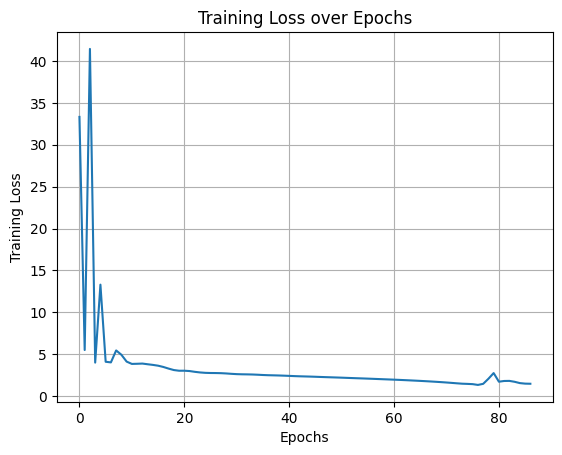

In [16]:
plt.plot(loss_plot)
plt.xlabel("Epochs")
plt.ylabel("Training Loss")
plt.title("Training Loss over Epochs")
plt.grid()
plt.show()

In [17]:
id_to_phoneme = {v: k for k, v in phoneme_to_id.items()}

In [18]:
def custom_ctc_decode(frame_preds, blank_id):
    decoded = []
    prev = None
    count = 0

    for p in frame_preds:
        p = int(p)

        if p != blank_id and p != prev:
            if decoded:
                decoded[-1]["count"] = count

            decoded.append({"char": p, "count": 0})
            count = 0

        prev = p
        count += 1

    if decoded:
        decoded[-1]["count"] = count

    return decoded

In [19]:
print(df.iloc[0]["phonemes"])

['ʔ', 'l', 'l', 'aa', 'h', 'u', 'l', 'aa', 'ʔ', 'i', 'l', 'aa', 'h', 'a', 'ʔ', 'i', 'l', 'l', 'aa', 'h', 'uu', '<sil>', 'l', 'a', 'y', 'a', 'jK', 'm', 'a', 'ʕ', 'a', 'nn', 'n', 'a', 'k', 'u', 'm', 'ʔ', 'i', 'l', 'aa', 'y', 'a', 'w', 'm', 'i', 'l', 'q', 'i', 'y', 'aa', 'm', 'a', 't', 'i', 'l', 'aa', 'rM', 'a', 'y', 'b', 'a', 'f', 'ii', 'h', '<sil>', 'w', 'a', 'm', 'a', 'n', 'ʔ', 'a', 'sˤ', 'd', 'a', 'q', 'u', 'm', 'i', 'n', 'a', 'l', 'l', 'aa', 'h', 'i', 'ħ', 'a', 'd', 'ii', 'θ', 'aa', '<sil>']


In [20]:
audio_path = df.iloc[0]["path_of_audio"]

waveforms = load_audio(
    os.path.join("../../datasets/Quran_ds/Quran_ds/audio/audio/", audio_path)
)

waveforms = waveforms.unsqueeze(0).to(DEVICE)  # (1, T)

print("waveforms", waveforms.shape)

model.eval()
with torch.no_grad():

    logits, features_len = model(wave, input_len)
    preds = logits.argmax(dim=2)
    preds = custom_ctc_decode(preds[0].cpu().numpy(), blank_id)
    print(preds)

    preds_tokens = [id_to_phoneme[p['char']] for p in preds]

    print("predicted tokens:", preds_tokens)

waveforms torch.Size([1, 1, 254932])
[{'char': 94, 'count': 3}, {'char': 104, 'count': 8}, {'char': 91, 'count': 785}]
predicted tokens: ['l', 'aa', 'f']


In [41]:
test_df= pd.read_csv("../../datasets/Quran_ds/quran_train_ds_phonemes.csv")
len(test_df)

29758

In [42]:
test_df = test_df[test_df['ds_index']==1]
len(test_df)

29721

In [ ]:
import librosa

def has_sil_at_middle(path):
    audio, _ = librosa.load(os.path.join("../../datasets/Quran_ds/Quran_ds/audio/audio",path), sr=16000)
    intervals = librosa.effects.split(
        audio,
        top_db=30,
        frame_length=2048,
        hop_length=512
    )

    return len(intervals) > 1

In [46]:
mask = test_df["path_of_audio"].apply(lambda x: has_sil_at_middle(x))
middle_sil_df = test_df[mask]
len(middle_sil_df)

9352

In [49]:
middle_sil_df.to_csv("../../datasets/Quran_ds/middle_sil_audios.csv")

In [48]:
def has_middle_sil(seq):
    return any(p == "<sil>" for p in seq[1:-1])


mask = middle_sil_df["phonemes"].apply(lambda x: not has_middle_sil(ast.literal_eval(x)))

middle_sil_df = middle_sil_df[mask]

len(middle_sil_df)

9105

In [50]:
df= pd.read_csv("../../datasets/Quran_ds/middle_sil_audios.csv")

In [51]:
len(df)

9105